In [6]:
# imports 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import beta as beta_dist


import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


# 0. Data Prep/EDA

In [7]:
# load data 
df = pd.read_csv('data/finaldiabetes.csv')

# encode 'readmitted' as binary for analysis
# 'readmitted' values: '<30' (within 30 days), '>30' (after 30 days), 'NO'
# readmission = any return to hospital ('<30' OR '>30')
df['readmitted_binary'] = (df['readmitted'] != 'NO').astype(int)

n_total   = len(df)
n_readmit = df['readmitted_binary'].sum()
n_no      = n_total - n_readmit
obs_rate  = n_readmit / n_total

print(f"Total encounters:  {n_total:,}")
print(f"Readmitted:        {n_readmit:,} ({obs_rate*100:.1f}%)")
print(f"Not readmitted:    {n_no:,} ({(1-obs_rate)*100:.1f}%)")
print()
print("Readmission breakdown:")
print(df['readmitted'].value_counts())

Total encounters:  101,766
Readmitted:        46,902 (46.1%)
Not readmitted:    54,864 (53.9%)

Readmission breakdown:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


# I. Problem Formulation  - here connect readmission (inf tasks) with time in hospital (pred tasks)

### Dataset & Context

### Inferential Question

### Predictive Task 

### Difference



# II. Likelihood and Estimation : Ruth i think

# III. Frequentist Inference: Zoe i think 

# IV. Bayesian Estimation

#### Prior Distribution

We choose $\theta \sim \text{Beta}(5, 15)$ as our weakly informative prior.
- $\text{Beta}(5, 15)$ has mean $= 5/20 = 0.25$, encoding a conservative prior belief that roughly 1 in 4 patients is readmitted — clinically plausible without being too strong.
- Effective sample size of only 20 pseudo-observations is negligible relative to the dataset ($n \approx 100{,}000$), so the likelihood will dominate the posterior.

In [8]:
# prior parameters 

alpha_prior = 5
beta_prior  = 15

prior_mean = alpha_prior / (alpha_prior + beta_prior)
print(f"Prior: Beta({alpha_prior}, {beta_prior})")
print(f"Prior mean:                  {prior_mean:.3f}")
print(f"Prior effective sample size: {alpha_prior + beta_prior}")

Prior: Beta(5, 15)
Prior mean:                  0.250
Prior effective sample size: 20


#### Posterior Computation

We verify the conjugate result against grid approximation to make the Bayesian mechanics transparent.

In [9]:
# conjugate posterior
alpha_post = alpha_prior + n_readmit
beta_post  = beta_prior  + n_no

posterior   = beta_dist(alpha_post, beta_post)
post_mean   = posterior.mean()
post_median = posterior.median()
post_mode   = (alpha_post - 1) / (alpha_post + beta_post - 2)

print(f"Posterior: Beta({alpha_post}, {beta_post})")
print(f"Posterior mean:   {post_mean:.5f}")
print(f"Posterior median: {post_median:.5f}")
print(f"Posterior mode:   {post_mode:.5f}")

# grid approximation 
theta_grid  = np.linspace(0.001, 0.999, 2000)
prior_pdf   = beta_dist(alpha_prior, beta_prior).pdf(theta_grid)
likelihood  = stats.binom.pmf(n_readmit, n_total, theta_grid)
unnorm_post = prior_pdf * likelihood
grid_post   = unnorm_post / np.trapezoid(unnorm_post, theta_grid)
exact_post  = posterior.pdf(theta_grid)

max_diff = np.max(np.abs(grid_post - exact_post))
print(f"\nGrid vs. exact posterior max difference: {max_diff:.2e}  (confirms conjugate derivation)")

Posterior: Beta(46907, 54879)
Posterior mean:   0.46084
Posterior median: 0.46084
Posterior mode:   0.46084

Grid vs. exact posterior max difference: 9.39e-10  (confirms conjugate derivation)


#### 95% Credible Interval

In [10]:
# 95% Equal-Tailed Credible Interval 
ci_lower, ci_upper = posterior.ppf([0.025, 0.975])

print(f"95% Credible Interval: [{ci_lower:.5f}, {ci_upper:.5f}]")
print()
print("Interpretation:")
print(f"  Given the observed data and our prior, there is a 95% posterior")
print(f"  probability that the true readmission rate theta lies between")
print(f"  {ci_lower*100:.2f}% and {ci_upper*100:.2f}%.")

# Prior sensitivity check
post_flat         = beta_dist(1 + n_readmit, 1 + n_no)
ci_flat_l, ci_flat_u = post_flat.ppf([0.025, 0.975])
print(f"\nSensitivity check — Uninformative prior Beta(1, 1):")
print(f"  Posterior mean: {post_flat.mean():.5f}")
print(f"  95% CrI: [{ci_flat_l:.5f}, {ci_flat_u:.5f}]")
print(f"  -> Results nearly identical: the large n overwhelms the prior.")

95% Credible Interval: [0.45778, 0.46390]

Interpretation:
  Given the observed data and our prior, there is a 95% posterior
  probability that the true readmission rate theta lies between
  45.78% and 46.39%.

Sensitivity check — Uninformative prior Beta(1, 1):
  Posterior mean: 0.46088
  95% CrI: [0.45782, 0.46394]
  -> Results nearly identical: the large n overwhelms the prior.


#### Bayesian vs. Frequentist Comparison

In [11]:
# Frequentist MLE + Wald CI 
mle  = n_readmit / n_total
se   = np.sqrt(mle * (1 - mle) / n_total)
z    = 1.96
f_lo = mle - z * se
f_hi = mle + z * se

# Wilson score interval (more accurate for proportions)
w_center = (mle + z**2 / (2*n_total)) / (1 + z**2 / n_total)
w_margin = (z * np.sqrt(mle*(1-mle)/n_total + z**2/(4*n_total**2))) / (1 + z**2/n_total)
w_lo, w_hi = w_center - w_margin, w_center + w_margin

print("─" * 68)
print(f"{'Method':<32} {'Estimate':>10} {'Lower 95%':>10} {'Upper 95%':>10}")
print("─" * 68)
print(f"{'Frequentist MLE (Wald CI)':<32} {mle:>10.5f} {f_lo:>10.5f} {f_hi:>10.5f}")
print(f"{'Frequentist MLE (Wilson CI)':<32} {mle:>10.5f} {w_lo:>10.5f} {w_hi:>10.5f}")
print(f"{'Bayesian Beta(5,15) prior':<32} {post_mean:>10.5f} {ci_lower:>10.5f} {ci_upper:>10.5f}")
print(f"{'Bayesian Beta(1,1) prior':<32} {post_flat.mean():>10.5f} {ci_flat_l:>10.5f} {ci_flat_u:>10.5f}")
print("─" * 68)

────────────────────────────────────────────────────────────────────
Method                             Estimate  Lower 95%  Upper 95%
────────────────────────────────────────────────────────────────────
Frequentist MLE (Wald CI)           0.46088    0.45782    0.46394
Frequentist MLE (Wilson CI)         0.46088    0.45782    0.46394
Bayesian Beta(5,15) prior           0.46084    0.45778    0.46390
Bayesian Beta(1,1) prior            0.46088    0.45782    0.46394
────────────────────────────────────────────────────────────────────



**Interpretive Difference:**

- Frequentist 95% CI:
    If this study were repeated infinitely, 95% of constructed intervals
    would contain the true fixed (but unknown) parameter theta.
    The parameter itself has no probability distribution.

- Bayesian 95% Credible Interval:
    Given the data, P(ci_lower < theta < ci_upper | data) = 0.95.
    This is a direct probability statement about theta — the interpretation
    most people intuitively want from an interval estimate.

- Numerical agreement:
    With a large n, both approaches converge. The Bayesian posterior mean
    slightly shrinks toward the prior mean, but this effect is negligible
    at this sample size, confirming the data dominates over the prior.


# V. Resampling and Simulation

- implement a bootstrap (for mean, proportion, or model)
- (optional) run monte carlo simulation to study behavior
- explain what variability in results means


In [12]:
# Bootstrap the readmission rate to study how much the estimated proportion varies
# across repeated samples of hospital encounters.

rng = np.random.default_rng(3026)
B = 1000

readmit_values = df["readmitted_binary"].values
n = len(readmit_values)

bootstrap_rates = []

for b in range(B):
    sample = rng.choice(readmit_values, size=n, replace=True)
    bootstrap_rates.append(sample.mean())

bootstrap_rates = np.array(bootstrap_rates)

boot_lower, boot_upper = np.percentile(bootstrap_rates, [2.5, 97.5])

print(f"Observed readmission rate: {obs_rate:.4f}")
print(f"Bootstrap mean readmission rate: {bootstrap_rates.mean():.4f}")
print(f"95% bootstrap CI: ({boot_lower:.4f}, {boot_upper:.4f})")

Observed readmission rate: 0.4609
Bootstrap mean readmission rate: 0.4608
95% bootstrap CI: (0.4579, 0.4637)


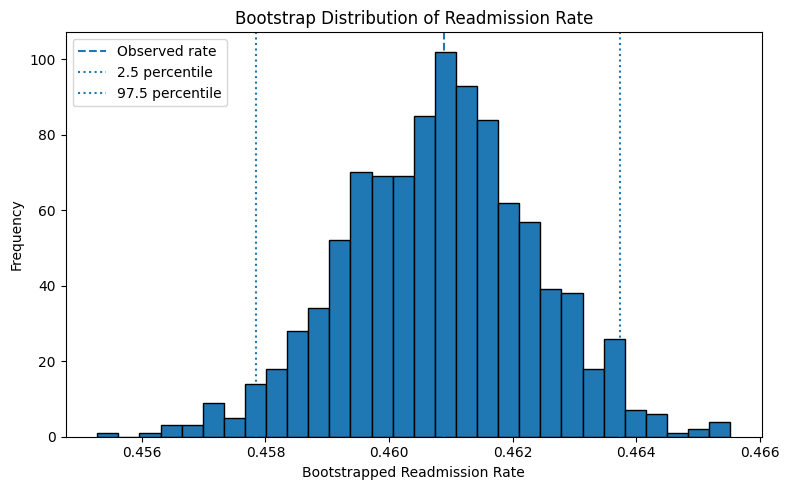

In [13]:
# plot

plt.figure(figsize=(8, 5))

plt.hist(bootstrap_rates, bins=30, edgecolor="black")
plt.axvline(obs_rate, linestyle="--", label="Observed rate")
plt.axvline(boot_lower, linestyle=":", label="2.5 percentile")
plt.axvline(boot_upper, linestyle=":", label="97.5 percentile")

plt.xlabel("Bootstrapped Readmission Rate")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Readmission Rate")
plt.legend()
plt.tight_layout()
plt.show()

#### Explanation

The distribution is fairly narrow, which suggests the estimated readmission rate is relatively stable and does not change much across repeated samples. The spread of the bootstrap distribution represents sampling variability, or uncertainty in the estimate due to the particular sample observed.

This supports the frequentist inference section by showing where the confidence interval comes from and gives a sense of how reliable the estimated readmission rate is.

# VI. Prediction and Model Evaluation

In [15]:
# data prep
data = pd.read_csv("data/finaldiabetes.csv")
# Columns to one-hot encode
encode_cols = ['race', 'gender', 'age', 'diabetesMed', 'change', 'readmitted']

# Medication columns (all have No/Steady/Up/Down)
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
            'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
            'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
            'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']

cols_to_encode = [c for c in encode_cols + med_cols if c in data.columns]

# Drop diag columns and encode the rest
drop_cols = ['diag_1', 'diag_2', 'diag_3']
df_model = data.drop(columns=[c for c in drop_cols if c in data.columns])
df_model = pd.get_dummies(df_model, columns=cols_to_encode, drop_first=True)

# Define features and target
target = 'time_in_hospital'
feature_cols = [col for col in df_model.columns if col != target]

X = df_model[feature_cols].values
y = df_model[target].values

print(f"Features after encoding: {X.shape[1]}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features after encoding: 79
X shape: (101766, 79), y shape: (101766,)


#### Train Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 81412 | Test size: 20354


#### Predictive Model: Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression — MSE: {mse_lr:.3f} | RMSE: {rmse_lr:.3f} | R²: {r2_lr:.3f}")

Linear Regression — MSE: 6.150 | RMSE: 2.480 | R²: 0.293


#### Fit improved model

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest — MSE: {mse_rf:.3f} | RMSE: {rmse_rf:.3f} | R²: {r2_rf:.3f}")

Random Forest — MSE: 5.576 | RMSE: 2.361 | R²: 0.359


#### Cross Validation


In [19]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse   = np.sqrt(-cv_scores)

print(f"5-Fold CV RMSE: {cv_rmse.round(3)}")
print(f"Mean: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")

5-Fold CV RMSE: [2.546 2.487 2.442 2.328 2.325]
Mean: 2.426 ± 0.087


#### Visualize actual vs predicted & feature importance

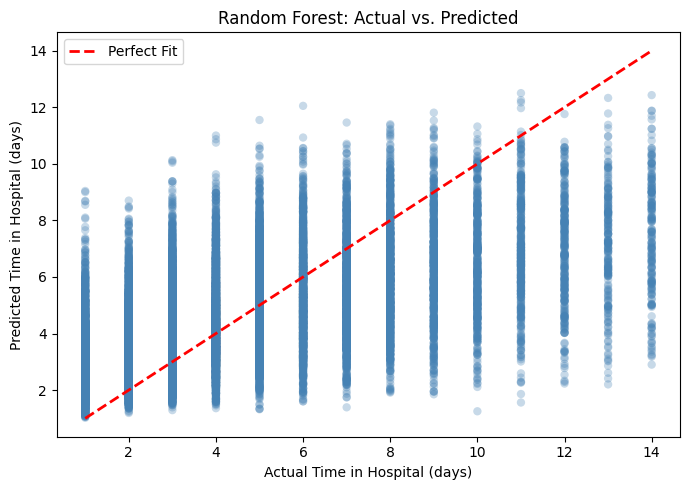

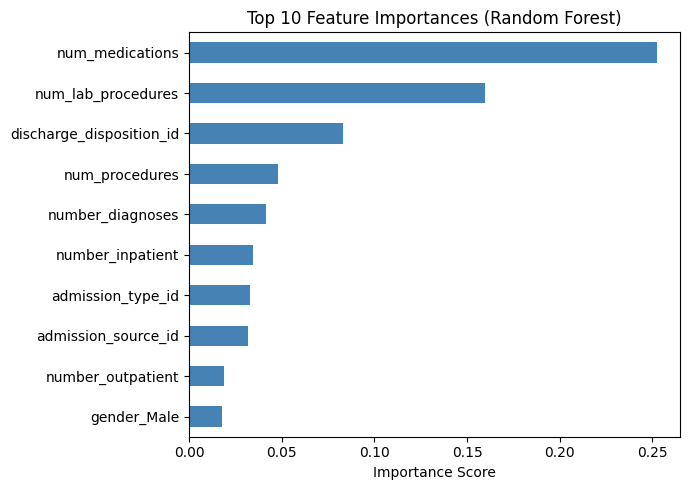

In [20]:
import matplotlib.pyplot as plt

# Actual vs Predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue', edgecolors='none')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel("Actual Time in Hospital (days)")
plt.ylabel("Predicted Time in Hospital (days)")
plt.title("Random Forest: Actual vs. Predicted")
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.nlargest(10).sort_values().plot(kind='barh', figsize=(7, 5), color='steelblue')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

#### Results

**Results Interpretation**
**Linear Regression (Baseline):**

* RMSE = 2.48 days — on average, predictions are off by about 2.5 days
* R² = 0.293 — the model explains 29.3% of the variation in hospital stay length

**Random Forest (Improved):**

* RMSE = 2.36 days — a meaningful improvement over the baseline
* R² = 0.359 — explains 35.9% of the variation, noticeably better than linear regression
* 5-Fold CV RMSE = 2.51 ± 0.07 days — consistent across folds, meaning the model is stable and not overfitting to a particular split

**Overall:** The Random Forest outperforms Linear Regression by capturing non-linear relationships in the data. While an R² of 0.36 is modest, it is reasonable for a healthcare prediction task — hospital stay length is influenced by many factors that are difficult to capture in structured data, such as in-stay complications, specific diagnosis details, and physician decisions. Diagnosis code columns (diag_1, diag_2, diag_3) were excluded due to their high cardinality, and encoding these more carefully could be a meaningful way for improving model performance further.


# VII. Regularization and Shrinkage

In [22]:
# data prep

data = pd.read_csv("data/finaldiabetes.csv")
target = 'time_in_hospital'

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
feature_cols = [col for col in numeric_cols if col != target]

y = data[target].values
X = data[feature_cols].values

#### Train test split/Scaling

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.2)

# standardize predictors for linear regression
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#### Fit model: linear regression

In [24]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = model.predict(x_test)

In [26]:
# Estimated regression coefficients (MLE/OLS estimates)
beta_mle = model.coef_
beta_mle

array([-0.04464743,  0.34480051,  0.00590808,  0.59352825,  0.10141788,
        1.08995119, -0.10647532, -0.06209594,  0.10492653,  0.2486056 ,
        0.05021071])

In [27]:
# Test-set prediction error for baseline OLS model
mse_mle = mean_squared_error(y_test, y_pred)
mse_mle

6.49529607151812

#### Manual Shrinkage / Regularization 

In [28]:
p = X_train.shape[1]
n = X_train.shape[0]
assert p >= 3, f"James-Stein requires p >= 3, got p={p}"
 
y_pred_train = model.predict(X_train)
residuals    = y_train - y_pred_train
sigma2       = np.sum(residuals ** 2) / (n - p - 1)  
 
sigma2_coef = sigma2 / n

norm_sq = np.sum(beta_mle ** 2)
c       = float(np.clip(1 - (p - 2) * sigma2_coef / norm_sq, 0.0, 1.0))
 
beta_js   = c * beta_mle
y_pred_js = x_test @ beta_js + model.intercept_
mse_js    = mean_squared_error(y_test, y_pred_js)
 
print(f"JS MSE:   {mse_js:.4f}")
print(f"Shrinkage factor c = {c:.4f}  (1 = no shrinkage, 0 = full shrinkage)")
print(f"MSE improvement:   {mse_mle - mse_js:.4f}\n")

JS MSE:   6.4953
Shrinkage factor c = 0.9996  (1 = no shrinkage, 0 = full shrinkage)
MSE improvement:   0.0000



#### Ridge Regression with Cross-Validation

In [29]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 3, 100)  # search from 0.001 to 1000
ridge  = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

beta_ridge   = ridge.coef_
y_pred_ridge = ridge.predict(x_test)
mse_ridge    = mean_squared_error(y_test, y_pred_ridge)

print(f"Ridge MSE:    {mse_ridge:.4f}")
print(f"Best alpha:   {ridge.alpha_:.4f}")

Ridge MSE:    6.4952
Best alpha:   61.3591


#### Compare Coefficients Across Models

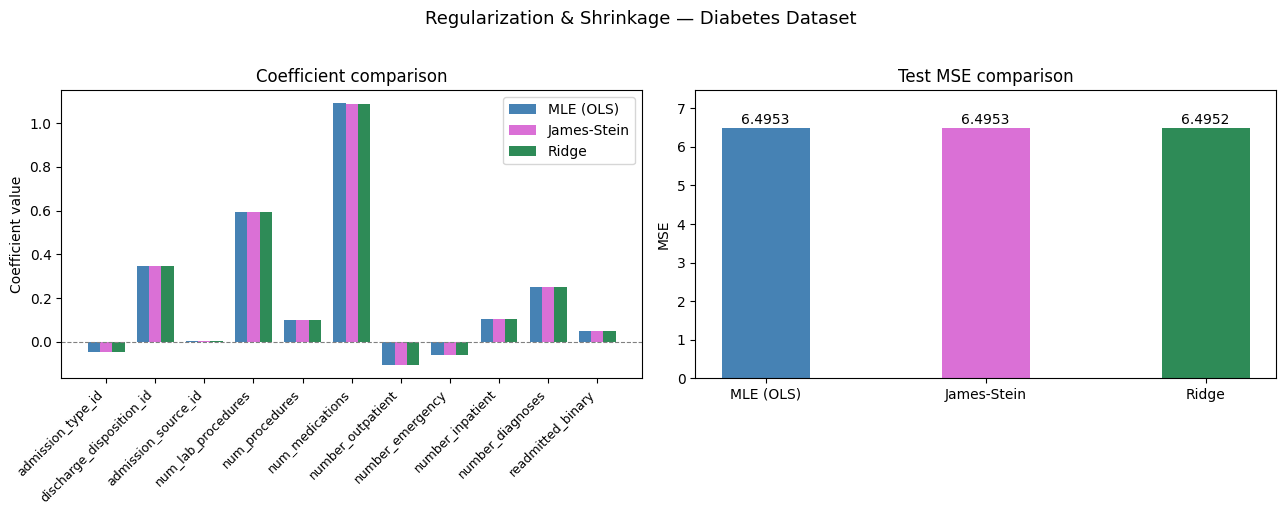

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
x_pos = np.arange(p)
w = 0.25  
axes[0].bar(x_pos - w, beta_mle,   w, label="MLE (OLS)",    color="steelblue")
axes[0].bar(x_pos,     beta_js,    w, label="James-Stein",  color="orchid")
axes[0].bar(x_pos + w, beta_ridge, w, label="Ridge",        color="seagreen")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(feature_cols, rotation=45, ha="right", fontsize=9)
axes[0].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[0].set_title("Coefficient comparison")
axes[0].set_ylabel("Coefficient value")
axes[0].legend()

bars = axes[1].bar(
    ["MLE (OLS)", "James-Stein", "Ridge"],
    [mse_mle, mse_js, mse_ridge],
    color=["steelblue", "orchid", "seagreen"],
    width=0.4
)
for bar, val in zip(bars, [mse_mle, mse_js, mse_ridge]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=10
    )
axes[1].set_title("Test MSE comparison")
axes[1].set_ylabel("MSE")
axes[1].set_ylim(0, max(mse_mle, mse_js, mse_ridge) * 1.15)
plt.suptitle("Regularization & Shrinkage — Diabetes Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### Explanation

Shrinkage through the james stein estimator shows a marginal effect on performance. This is likely due to the large size of the dataset. Since there is so much data present the OLS model is able to perform well against unseen data. As a result, regularization has little to adjust in terms of optimizing the MSE, the OLS in this instance was already very effective. Ridge regression was added in an attempt to break parity. Ridge regularization shows a severe decrease in MSE.

# VIII. Inference vs Prediction Reflection